STEP 1 : Visualizing noise in a simple two H gates system

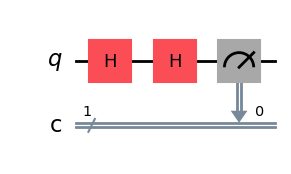

In [44]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

#1 qubit, 1 bit classique pour stocker la mesure
qc = QuantumCircuit(1,1) #Initialisation of |0> by default
qc.h(0) # Hadamard gate
qc.h(0) # Hadamard gate H.H = I
qc.measure(0,0) # Mesure du qubit 0 dans le bit classique 0

qc.draw('mpl') # Affiche le circuit

In [45]:
simulator = AerSimulator()
qc_t = transpile(qc, simulator, optimization_level=0) # Adapts the circuit to the gates of the simulator
result = simulator.run(qc_t, shots=10000).result() #Execute the circuit 10000 times
counts = result.get_counts()
print("Counts:", counts) #counts is a dictionary {'0': 10000} because the state |0> is measured 10000 times, as expected.

# Probabilité de empirique de mesirer |0>
prob_0 = counts.get('0', 0) / 10000
print(f"P(|0>) = {prob_0:.4f}")

Counts: {'0': 10000}
P(|0>) = 1.0000


In [46]:
from qiskit_aer.noise import NoiseModel, depolarizing_error

p = 0.1
error_1q = depolarizing_error(p, 1) #1 bit canal, parameter p

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(error_1q, ['h']) # Adds the error to all qubits for the Hadamard gate

print(noise_model)

NoiseModel:
  Basis gates: ['cx', 'h', 'id', 'rz', 'sx']
  Instructions with noise: ['h']
  All-qubits errors: ['h']


rho -> (1-p).rho + p.I

In [47]:
noisy_sim = AerSimulator(noise_model=noise_model)
qc_t = transpile(qc, noisy_sim, optimization_level=0)
print("Circuit original :")
print(qc)
print("\nCircuit transpilé :")
print(qc_t)
result = noisy_sim.run(qc_t, shots=10000).result()
counts = result.get_counts()

prob_0 = counts.get('0', 0) / 10000
print(f"Counts with noise: {counts}")
print(f"P(|0>) with noise = {prob_0:.4f}")

Circuit original :
     ┌───┐┌───┐┌─┐
  q: ┤ H ├┤ H ├┤M├
     └───┘└───┘└╥┘
c: 1/═══════════╩═
                0 

Circuit transpilé :
     ┌───┐┌───┐┌─┐
  q: ┤ H ├┤ H ├┤M├
     └───┘└───┘└╥┘
c: 1/═══════════╩═
                0 
Counts with noise: {'0': 9007, '1': 993}
P(|0>) with noise = 0.9007


STEP 2 : Implementing circuit folding for any odd number lambda

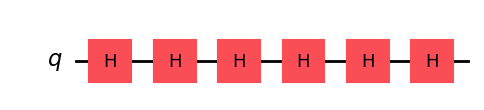

In [48]:
#Separating the unitary part from the measure part
qc_u = QuantumCircuit(1)
qc_u.h(0)
qc_u.h(0)

def fold_circuit_integer(qc_u, n):
    #Applies U -> U(U^daggerU)^n to a measureless circuit
    folded = qc_u.copy()
    for _ in range(n):
        folded = folded.compose(qc_u.inverse()) #inverses the order of the gates and applies a daggerto each one
        folded = folded.compose(qc_u)
    return folded

qc_folded = fold_circuit_integer(qc_u, 1)
qc_folded.draw('mpl')

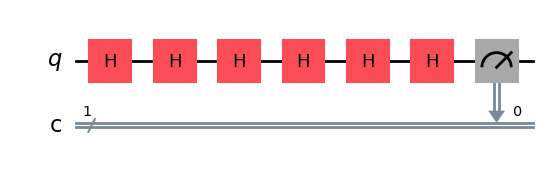

Counts for folded circuit without noise: {'0': 10000}


In [49]:
# Noiseless execution
qc_folded_with_meas = QuantumCircuit(1,1)
qc_folded_with_meas = qc_folded_with_meas.compose(qc_folded)
qc_folded_with_meas.measure(0,0)

display(qc_folded_with_meas.draw('mpl'))

ideal_sim = AerSimulator()
qc_t = transpile(qc_folded_with_meas, ideal_sim, optimization_level=0)
counts = ideal_sim.run(qc_t, shots=10000).result().get_counts()
print(f"Counts for folded circuit without noise: {counts}")

In [50]:
#With noise
sim = AerSimulator(noise_model=noise_model)
qc_t = transpile(qc_folded_with_meas, sim, optimization_level=0)
counts = sim.run(qc_t, shots=10000).result().get_counts()
prob_0 = counts.get('0', 0) / 10000
print(f"Counts for folded circuit with noise: {counts}")
print(f"Bruité, n=1 : P(|0>) = {prob_0:.4f}")

Counts for folded circuit with noise: {'0': 7639, '1': 2361}
Bruité, n=1 : P(|0>) = 0.7639


STEP 3 : Generalizing for any real lambda

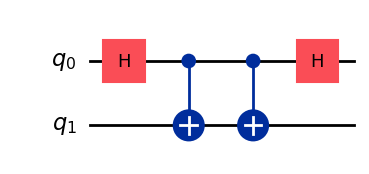

In [51]:
#Precision on lambda depends on the depth of the circuit (2/lambda),
#so we increase it to d=4.

qc_u = QuantumCircuit(2)
qc_u.h(0)         # superposition sur q0
qc_u.cx(0, 1)     # intrication : on entre dans (|00>+|11>)/sqrt(2)
qc_u.cx(0, 1)     # désintrication : on retombe sur |+>|0>
qc_u.h(0)         # on défait la superposition : retour à |00>

display(qc_u.draw('mpl'))

#New noise model that includes 2 qubits gates
p1 = 0.01   # taux pour les portes 1-qubit
p2 = 0.05   # taux pour les CX (typiquement plus bruitées en pratique)

nm = NoiseModel()
nm.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ['h'])
nm.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ['id'])
nm.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ['rz'])
nm.add_all_qubit_quantum_error(depolarizing_error(p1, 1), ['sx'])
nm.add_all_qubit_quantum_error(depolarizing_error(p2, 2), ['cx'])

#New simulator with the new noise model
sim = AerSimulator(noise_model=nm)

In [52]:
#Generalized folding for any lambda

def fold_circuit(qc_u, scale_factor):
    
    d = len(qc_u.data) #depth of the circuit

    #1) Integer k closest to d(lambda-1)/2
    k = round(d*(scale_factor-1)/2)

    #2) n = quotient, s = rest
    n, s = divmod(k, d)

    lambda_actual = 1 + 2*k/d
    print(f"λ demandé = {scale_factor} → n = {n}, s = {s}, λ effectif = {lambda_actual:.3f}")

    #3) Construction du circuit
    folded = qc_u.copy()

    for _ in range(n):
        folded = folded.compose(qc_u.inverse())
        folded = folded.compose(qc_u)

    if s > 0:
        last_s = QuantumCircuit(qc_u.num_qubits) #Empty circuit with the same number of qubits as qc_u
        for instr in qc_u.data[-s:]:
            indices = [qc_u.find_bit(q).index for q in instr.qubits]
            last_s.append(instr.operation, indices)
        folded = folded.compose(last_s.inverse())
        folded = folded.compose(last_s)

    return folded

λ demandé = 1.0 → n = 0, s = 0, λ effectif = 1.000


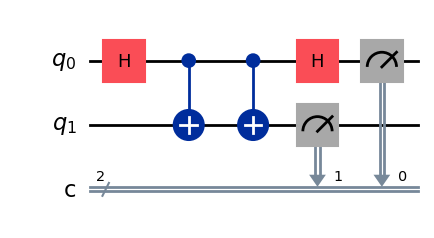

Counts for λ=1.0: {'00': 9201, '01': 342, '11': 220, '10': 237}
  → P(|00>) = 0.9201

λ demandé = 1.5 → n = 0, s = 1, λ effectif = 1.500


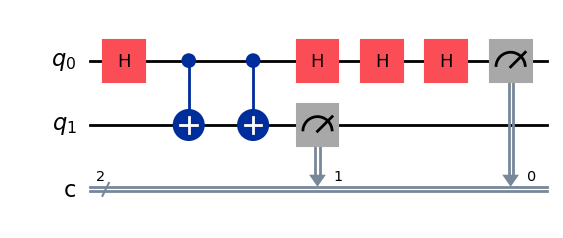

Counts for λ=1.5: {'00': 9095, '01': 427, '11': 242, '10': 236}
  → P(|00>) = 0.9095

λ demandé = 2.0 → n = 0, s = 2, λ effectif = 2.000


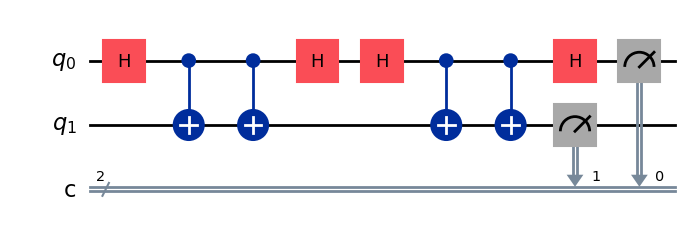

Counts for λ=2.0: {'00': 8412, '10': 492, '01': 618, '11': 478}
  → P(|00>) = 0.8412



In [53]:
#Test
for lam in [1.0, 1.5, 2.0]:
    qc_folded = fold_circuit(qc_u, lam)
    
    qc_with_meas = QuantumCircuit(2, 2)
    qc_with_meas = qc_with_meas.compose(qc_folded)
    qc_with_meas.measure([0, 1], [0, 1])
    
    qc_t = transpile(qc_with_meas, sim, optimization_level=0)

    display(qc_t.draw('mpl'))

    counts = sim.run(qc_t, shots=10000).result().get_counts()
    print(f"Counts for λ={lam}: {counts}")
    prob_0 = counts.get('00', 0) / 10000
    print(f"  → P(|00>) = {prob_0:.4f}\n")

STEP 4 : loop over lambda and tocking data

In [54]:
#Helper function to contract everything done in one step

import numpy as np
import matplotlib.pyplot as plt

def measure_expectation(qc_u, scale_factor, sim, shots=10000):
    """Folds the cicuit fo a given lambda, measures, and returns P(|0...0>)"""
    qc_folded = fold_circuit(qc_u, scale_factor)

    n = qc_u.num_qubits
    qc_with_meas = QuantumCircuit(n, n)
    qc_with_meas = qc_with_meas.compose(qc_folded)
    qc_with_meas.measure(range(n), range(n))

    qc_t = transpile(qc_with_meas, sim, optimization_level=0)
    counts = sim.run(qc_t, shots=shots).result().get_counts()

    return counts.get('0'*n, 0) / shots
    

In [55]:
#loop

lambdas = np.array([1.0, 1.5, 2.0, 2.5, 3.0])
expectations = np.zeros(len(lambdas))

for i, lam in enumerate(lambdas):
    expectations[i] = measure_expectation(qc_u, lam, sim)
    print(f"λ={lam} → P(|00>)={expectations[i]:.4f}")

λ demandé = 1.0 → n = 0, s = 0, λ effectif = 1.000
λ=1.0 → P(|00>)=0.9148
λ demandé = 1.5 → n = 0, s = 1, λ effectif = 1.500
λ=1.5 → P(|00>)=0.9089
λ demandé = 2.0 → n = 0, s = 2, λ effectif = 2.000
λ=2.0 → P(|00>)=0.8512
λ demandé = 2.5 → n = 0, s = 3, λ effectif = 2.500
λ=2.5 → P(|00>)=0.7918
λ demandé = 3.0 → n = 1, s = 0, λ effectif = 3.000
λ=3.0 → P(|00>)=0.7907


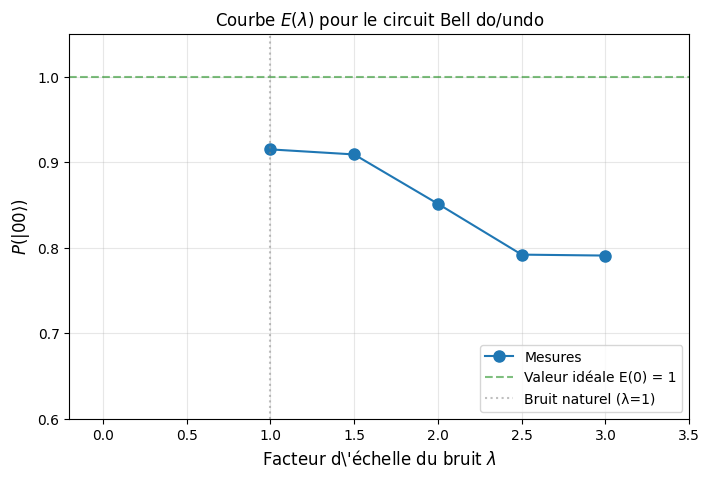

In [56]:
#visualization
plt.figure(figsize=(8, 5))
plt.plot(lambdas, expectations, 'o-', markersize=8, linewidth=1.5, label='Mesures')
plt.axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Valeur idéale E(0) = 1')
plt.axvline(x=1.0, color='gray', linestyle=':', alpha=0.5, label='Bruit naturel (λ=1)')
plt.xlabel(r'Facteur d\'échelle du bruit $\lambda$', fontsize=12)
plt.ylabel(r'$P(|00\rangle)$', fontsize=12)
plt.title(r'Courbe $E(\lambda)$ pour le circuit Bell do/undo', fontsize=12)
plt.xlim(-0.2, 3.5)
plt.ylim(0.6, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

STEP 5 : fit and extrapolation (polynomial order 2) towards lambda = 0

In [57]:
#polynomial fit (least squares)
coeffs = np.polyfit(lambdas, expectations, deg=2)
poly = np.poly1d(coeffs)

#Extrapolation to λ=0
E_mitigated = poly(0)
E_unmitigated = expectations[0] #corresponds to λ=1
E_ideal = 1.0

print(f"Coefficients [c2, c1, c0] = {coeffs}")
print(f"E(0) extrapolated   = {E_mitigated:.4f}")
print(f"E(1) raw        = {E_unmitigated:.4f}")
print(f"E(0) ideal       = {E_ideal:.4f}")
print(f"Raw error        = {abs(E_ideal - E_unmitigated):.4f}")
print(f"Mitigated error  = {abs(E_ideal - E_mitigated):.4f}")
print(f"Reduction factor = {abs(E_ideal - E_unmitigated) / abs(E_ideal - E_mitigated):.2f}×")

Coefficients [c2, c1, c0] = [ 0.00225714 -0.08208857  1.0055    ]
E(0) extrapolated   = 1.0055
E(1) raw        = 0.9148
E(0) ideal       = 1.0000
Raw error        = 0.0852
Mitigated error  = 0.0055
Reduction factor = 15.49×


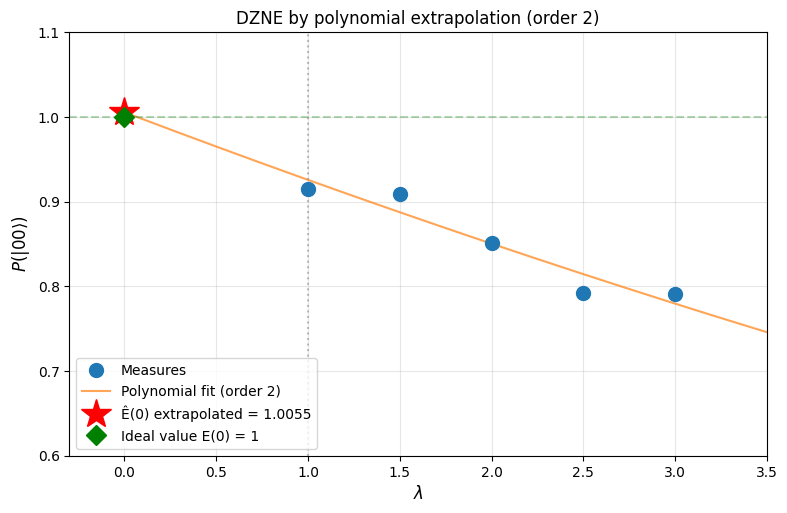

In [58]:
lam_dense = np.linspace(0, 3.5, 200)

plt.figure(figsize=(9, 5.5))
plt.plot(lambdas, expectations, 'o', markersize=10, label='Measures', zorder=3)
plt.plot(lam_dense, poly(lam_dense), '-', alpha=0.7, label='Polynomial fit (order 2)')
plt.plot(0, E_mitigated, '*', markersize=22, color='red', 
         label=f'Ê(0) extrapolated = {E_mitigated:.4f}', zorder=4)
plt.plot(0, 1.0, 'D', markersize=10, color='green', 
         label='Ideal value E(0) = 1', zorder=4)
plt.axhline(y=1.0, color='green', linestyle='--', alpha=0.3)
plt.axvline(x=1.0, color='gray', linestyle=':', alpha=0.5)
plt.xlabel(r'$\lambda$', fontsize=12)
plt.ylabel(r'$P(|00\rangle)$', fontsize=12)
plt.title('DZNE by polynomial extrapolation (order 2)')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.xlim(-0.3, 3.5)
plt.ylim(0.6, 1.1)
plt.show()

STEP 6 : Randomized benchmarking on Clifford gates (H CX S)

Profondeur du circuit : 18
Nombre total de portes : 20


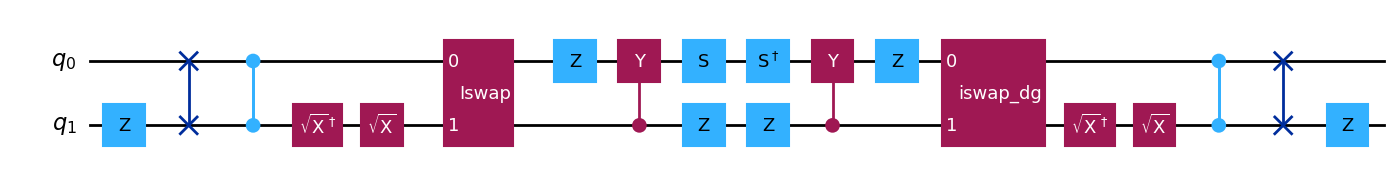

λ demandé = 1.0 → n = 0, s = 0, λ effectif = 1.000
λ = 1.0 → P(|00>) = 0.5563
λ demandé = 1.5 → n = 0, s = 5, λ effectif = 1.500
λ = 1.5 → P(|00>) = 0.4382
λ demandé = 2.0 → n = 0, s = 10, λ effectif = 2.000
λ = 2.0 → P(|00>) = 0.3709
λ demandé = 2.5 → n = 0, s = 15, λ effectif = 2.500
λ = 2.5 → P(|00>) = 0.3255
λ demandé = 3.0 → n = 1, s = 0, λ effectif = 3.000
λ = 3.0 → P(|00>) = 0.2973

E(1) brut             = 0.5563
E(0) extrapolé        = 0.8516
E(0) idéal            = 1.0000
Erreur brute          = 0.4437
Erreur mitigée        = 0.1484
Facteur de réduction  = 2.99×


In [59]:
from qiskit.circuit.random import random_clifford_circuit

# Génération du circuit aléatoire qui retombe sur |00> idéalement
rand_circ = random_clifford_circuit(num_qubits=2, num_gates=10, seed=42)
rand_circ.compose(rand_circ.inverse(), inplace=True)

print(f"Profondeur du circuit : {rand_circ.depth()}")
print(f"Nombre total de portes : {len(rand_circ.data)}")
display(rand_circ.draw('mpl'))

# Boucle ZNE
lambdas = np.array([1.0, 1.5, 2.0, 2.5, 3.0])
expectations = np.zeros(len(lambdas))

for i, lam in enumerate(lambdas):
    expectations[i] = measure_expectation(rand_circ, lam, sim)
    print(f"λ = {lam} → P(|00>) = {expectations[i]:.4f}")

# Fit et extrapolation
coeffs = np.polyfit(lambdas, expectations, deg=2)
poly = np.poly1d(coeffs)

E_mitigated = poly(0)
E_unmitigated = expectations[0]
E_ideal = 1.0

print(f"\nE(1) brut             = {E_unmitigated:.4f}")
print(f"E(0) extrapolé        = {E_mitigated:.4f}")
print(f"E(0) idéal            = {E_ideal:.4f}")
print(f"Erreur brute          = {abs(E_ideal - E_unmitigated):.4f}")
print(f"Erreur mitigée        = {abs(E_ideal - E_mitigated):.4f}")
print(f"Facteur de réduction  = {abs(E_ideal - E_unmitigated) / abs(E_ideal - E_mitigated):.2f}×")

In [60]:
seeds = range(20)  # 20 circuits aléatoires différents
improvements = []
errors_unmit = []
errors_mit = []

for seed in seeds:
    rand_circ = random_clifford_circuit(num_qubits=2, num_gates=11, seed=seed)
    rand_circ.compose(rand_circ.inverse(), inplace=True)
    
    expectations = np.array([measure_expectation(rand_circ, lam, sim) for lam in lambdas])
    poly = np.poly1d(np.polyfit(lambdas, expectations, deg=2))
    
    err_u = abs(1.0 - expectations[0])
    err_m = abs(1.0 - poly(0))
    errors_unmit.append(err_u)
    errors_mit.append(err_m)
    improvements.append(err_u / err_m if err_m > 0 else np.inf)

print(f"Erreur brute moyenne     : {np.mean(errors_unmit):.4f} ± {np.std(errors_unmit):.4f}")
print(f"Erreur mitigée moyenne   : {np.mean(errors_mit):.4f} ± {np.std(errors_mit):.4f}")
print(f"Facteur d'amélioration moyen : {np.mean(improvements):.2f}× (médiane {np.median(improvements):.2f}×)")

λ demandé = 1.0 → n = 0, s = 0, λ effectif = 1.000
λ demandé = 1.5 → n = 0, s = 6, λ effectif = 1.545
λ demandé = 2.0 → n = 0, s = 11, λ effectif = 2.000
λ demandé = 2.5 → n = 0, s = 16, λ effectif = 2.455
λ demandé = 3.0 → n = 1, s = 0, λ effectif = 3.000
λ demandé = 1.0 → n = 0, s = 0, λ effectif = 1.000
λ demandé = 1.5 → n = 0, s = 6, λ effectif = 1.545
λ demandé = 2.0 → n = 0, s = 11, λ effectif = 2.000
λ demandé = 2.5 → n = 0, s = 16, λ effectif = 2.455
λ demandé = 3.0 → n = 1, s = 0, λ effectif = 3.000
λ demandé = 1.0 → n = 0, s = 0, λ effectif = 1.000
λ demandé = 1.5 → n = 0, s = 6, λ effectif = 1.545
λ demandé = 2.0 → n = 0, s = 11, λ effectif = 2.000
λ demandé = 2.5 → n = 0, s = 16, λ effectif = 2.455
λ demandé = 3.0 → n = 1, s = 0, λ effectif = 3.000
λ demandé = 1.0 → n = 0, s = 0, λ effectif = 1.000
λ demandé = 1.5 → n = 0, s = 6, λ effectif = 1.545
λ demandé = 2.0 → n = 0, s = 11, λ effectif = 2.000
λ demandé = 2.5 → n = 0, s = 16, λ effectif = 2.455
λ demandé = 3.0 → n = 1

STEP 7 : Adaptative extrapolation

In [61]:
#Silent version of the functions, without print statements, for easier use in loops and with many circuits.

from scipy.optimize import curve_fit

def fold_circuit_silent(qc_u, scale_factor):
    """Folding U → U(U†U)^n U†_s U_s pour λ ≥ 1 quelconque. Aucun print."""
    d = len(qc_u.data)
    k = round(d * (scale_factor - 1) / 2)
    n, s = divmod(k, d)
    folded = qc_u.copy()
    for _ in range(n):
        folded = folded.compose(qc_u.inverse())
        folded = folded.compose(qc_u)
    if s > 0:
        last_s = QuantumCircuit(qc_u.num_qubits)
        for instr in qc_u.data[-s:]:
            indices = [qc_u.find_bit(q).index for q in instr.qubits]
            last_s.append(instr.operation, indices)
        folded = folded.compose(last_s.inverse())
        folded = folded.compose(last_s)
    return folded

def measure_expectation_silent(qc_u, scale_factor, sim, shots=10000):
    """Mesure de P(|0...0>) après folding au facteur λ. Aucun print."""
    qc_folded = fold_circuit_silent(qc_u, scale_factor)
    n = qc_u.num_qubits
    qc_with_meas = QuantumCircuit(n, n)
    qc_with_meas = qc_with_meas.compose(qc_folded)
    qc_with_meas.measure(range(n), range(n))
    qc_t = transpile(qc_with_meas, sim, optimization_level=0)
    counts = sim.run(qc_t, shots=int(shots)).result().get_counts()
    return counts.get('0' * n, 0) / int(shots)

In [62]:
# algorthme 3 du papier DZNE, avec un modèle exponentiel

def fit_exp_known_a(lambdas_arr, ys_arr, a_known, c_init=1.0):
    """Ajuste b, c dans y = a + b·exp(-c·λ) à a fixé."""
    def model(lam, b, c):
        return a_known + b * np.exp(-c * lam)
    try:
        b_init = max(ys_arr[0] - a_known, 1e-3)
        popt, _ = curve_fit(model, lambdas_arr, ys_arr,
                            p0=[b_init, c_init], maxfev=10000)
        return float(popt[0]), float(popt[1])
    except Exception:
        return None, None


def adaptive_exponential_zne(qc_u, sim, a_known, N_max, N_batch, lambda_1=1.0):
    """Algorithme 3 du papier DZNE.

    Renvoie : (E_hat_0, lambdas_visités, y_mesurés, N_par_mesure, params_finaux)
    """
    alpha = 1.27846                    # racine numérique de Eq. (42)
    c = 1.0                            # devine initiale pour c
    lambdas_list, ys_list, Ns_list = [], [], []
    N_used = 0

    while N_used < N_max:
        # λ_2 d'après l'estimation courante de c
        lambda_2 = lambda_1 + alpha / c

        # Allocation N_1, N_2 (Eq. 40 du papier)
        denom = c * lambda_1 + alpha - 1.0
        N_1 = max(int(round(N_batch * (c * lambda_1 / alpha) / denom)), 1)
        N_2 = max(int(round(N_batch * ((1.0 + c * lambda_1 / alpha) * (alpha - 1.0)) / denom)), 1)

        # Plafonner au budget restant
        if N_used + N_1 + N_2 > N_max:
            remaining = N_max - N_used
            if remaining < 2:
                break
            ratio = N_1 / max(N_1 + N_2, 1)
            N_1 = max(int(round(remaining * ratio)), 1)
            N_2 = max(remaining - N_1, 1)

        # Mesurer
        y_1 = measure_expectation_silent(qc_u, lambda_1, sim, shots=N_1)
        y_2 = measure_expectation_silent(qc_u, lambda_2, sim, shots=N_2)
        N_used += N_1 + N_2

        lambdas_list += [lambda_1, lambda_2]
        ys_list      += [y_1, y_2]
        Ns_list      += [N_1, N_2]

        # Refit sur l'historique complet
        b_new, c_new = fit_exp_known_a(np.array(lambdas_list),
                                       np.array(ys_list),
                                       a_known, c_init=c)
        if c_new is not None and c_new > 1e-6:
            c = c_new   # mise à jour de l'estimation de c

    # Estimateur final
    b_f, c_f = fit_exp_known_a(np.array(lambdas_list), np.array(ys_list),
                               a_known, c_init=c)
    if b_f is None:
        b_f, c_f = (ys_list[0] - a_known), c
    return a_known + b_f, lambdas_list, ys_list, Ns_list, (a_known, b_f, c_f)

In [63]:
# Algorthme 2 instancié avec un modèle polynomial.

def _predicted_var_E0(lams, Ns, sigma_hat_sq, degree):
    """Var(Ê(0)) en moindres carrés pondérés sur un polynôme de degré donné."""
    lams = np.asarray(lams, dtype=float)
    Ns   = np.asarray(Ns,   dtype=float)
    # poids ∝ N (précision inverse à σ²/N)
    W = np.diag(Ns / Ns.mean())
    V = np.vander(lams, degree + 1)   # colonnes [λ^d, λ^{d-1}, ..., 1]
    A = V.T @ W @ V
    try:
        Ainv = np.linalg.inv(A)
    except np.linalg.LinAlgError:
        return np.inf
    e0 = np.zeros(degree + 1); e0[-1] = 1.0   # Ê(0) = coefficient constant
    return float(sigma_hat_sq * (e0 @ Ainv @ e0))


def adaptive_polynomial_zne(qc_u, sim, degree, N_max, N_batch,
                            initial_lambdas, candidate_lambdas):
    """Algorithme 2 instancié avec un modèle polynomial.

    NewScale : choisit la candidate qui minimise Var(Ê(0)) prédite.
    NewNumSamples : N_batch constant.
    """
    lambdas_list, ys_list, Ns_list = [], [], []
    N_used = 0

    # Mesures initiales (besoin de ≥ degree+1 points pour un fit)
    for lam in initial_lambdas:
        y = measure_expectation_silent(qc_u, lam, sim, shots=N_batch)
        lambdas_list.append(lam)
        ys_list.append(y)
        Ns_list.append(N_batch)
        N_used += N_batch

    while N_used < N_max:
        # BestFit
        try:
            coeffs = np.polyfit(lambdas_list, ys_list, deg=degree)
        except Exception:
            coeffs = np.zeros(degree + 1)
        poly = np.poly1d(coeffs)

        # Variance résiduelle estimée (ddof = nb. paramètres ajustés)
        resid = np.array(ys_list) - poly(np.array(lambdas_list))
        ddof = min(degree, len(resid) - 1)
        sigma_hat_sq = max(np.var(resid, ddof=ddof), 1e-8)

        # NewScale : minimiser Var(Ê(0)) prédite après ajout
        best_lam, best_v = None, np.inf
        for cand in candidate_lambdas:
            test_lams = lambdas_list + [cand]
            test_Ns   = Ns_list + [N_batch]
            v = _predicted_var_E0(test_lams, test_Ns, sigma_hat_sq, degree)
            if v < best_v:
                best_v = v
                best_lam = cand
        if best_lam is None:
            best_lam = candidate_lambdas[0]

        # NewNumSamples
        N_next = min(N_batch, N_max - N_used)
        if N_next < 100:
            break

        # Mesurer
        y_next = measure_expectation_silent(qc_u, best_lam, sim, shots=N_next)
        lambdas_list.append(best_lam)
        ys_list.append(y_next)
        Ns_list.append(N_next)
        N_used += N_next

    coeffs = np.polyfit(lambdas_list, ys_list, deg=degree)
    return float(np.poly1d(coeffs)(0)), lambdas_list, ys_list, Ns_list

In [64]:
# Non-adaptive versions for comparison

def nonadaptive_poly_zne(qc_u, sim, degree, lambdas, shots_per_lambda):
    lambdas = np.asarray(lambdas, dtype=float)
    ys = np.array([measure_expectation_silent(qc_u, l, sim, shots=shots_per_lambda)
                   for l in lambdas])
    coeffs = np.polyfit(lambdas, ys, deg=degree)
    return float(np.poly1d(coeffs)(0))


def nonadaptive_exp_zne(qc_u, sim, a_known, lambdas, shots_per_lambda):
    lambdas = np.asarray(lambdas, dtype=float)
    ys = np.array([measure_expectation_silent(qc_u, l, sim, shots=shots_per_lambda)
                   for l in lambdas])
    b, c = fit_exp_known_a(lambdas, ys, a_known, c_init=0.5)
    if b is None:
        return float(ys[0])
    return float(a_known + b)

In [65]:
#Benchmarking de tous les algorithmes sur des circuits aléatoires

from qiskit.circuit.random import random_clifford_circuit
import time


budgets  = [2000, 4000, 6000, 8000, 10000]
seeds    = list(range(8))
ideal    = 1.0
a_known  = 0.25                                # 2 qubits → 1/2^2
lams_grid  = [1.0, 1.5, 2.0, 2.5, 3.0]
candidates = [1.0, 1.5, 2.0, 2.5, 3.0]

methods = ['unmit', 'poly2_nonad', 'exp_nonad', 'alg3', 'alg2_poly2']
results = {m: {B: [] for B in budgets} for m in methods}

t0 = time.time()
for seed in seeds:
    rc = random_clifford_circuit(num_qubits=2, num_gates=10, seed=seed)
    rc.compose(rc.inverse(), inplace=True)
    for B in budgets:
        # Unmitigated : tout le budget à λ=1
        y_un = measure_expectation_silent(rc, 1.0, sim, shots=B)
        results['unmit'][B].append(abs(ideal - y_un))

        per = B // len(lams_grid)
        results['poly2_nonad'][B].append(
            abs(ideal - nonadaptive_poly_zne(rc, sim, 2, lams_grid, per)))
        results['exp_nonad'][B].append(
            abs(ideal - nonadaptive_exp_zne(rc, sim, a_known, lams_grid, per)))

        E3, *_ = adaptive_exponential_zne(rc, sim, a_known, B, N_batch=max(B//4, 500))
        results['alg3'][B].append(abs(ideal - E3))

        N_batch2 = max(B // 6, 400)
        if 3 * N_batch2 > B:
            N_batch2 = B // 4
        E2, *_ = adaptive_polynomial_zne(
            rc, sim, degree=2, N_max=B, N_batch=N_batch2,
            initial_lambdas=[1.0, 2.0, 3.0],
            candidate_lambdas=candidates)
        results['alg2_poly2'][B].append(abs(ideal - E2))

print(f"Temps total : {time.time()-t0:.1f} s")

# Tableau résumé
print(f"\n{'budget':>8}  {'unmit':>8}  {'poly2':>8}  {'exp':>8}  {'alg3':>8}  {'alg2':>8}")
for B in budgets:
    print(f"{B:>8}  "
          f"{np.mean(results['unmit'][B]):>8.4f}  "
          f"{np.mean(results['poly2_nonad'][B]):>8.4f}  "
          f"{np.mean(results['exp_nonad'][B]):>8.4f}  "
          f"{np.mean(results['alg3'][B]):>8.4f}  "
          f"{np.mean(results['alg2_poly2'][B]):>8.4f}")

C:\Users\thoma\AppData\Local\Temp\ipykernel_30572\2166017494.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(model, lambdas_arr, ys_arr,
C:\Users\thoma\AppData\Local\Temp\ipykernel_30572\2166017494.py:6: RuntimeWarning: overflow encountered in exp
  return a_known + b * np.exp(-c * lam)


Temps total : 50.2 s

  budget     unmit     poly2       exp      alg3      alg2
    2000    0.4898    0.2194    0.1724    0.1607    0.2341
    4000    0.4786    0.2095    0.1248    0.1414    0.1562
    6000    0.4832    0.2004    0.0842    0.0623    0.2169
    8000    0.4815    0.2081    0.0933    0.0766    0.2153
   10000    0.4799    0.2434    0.0843    0.0689    0.2050


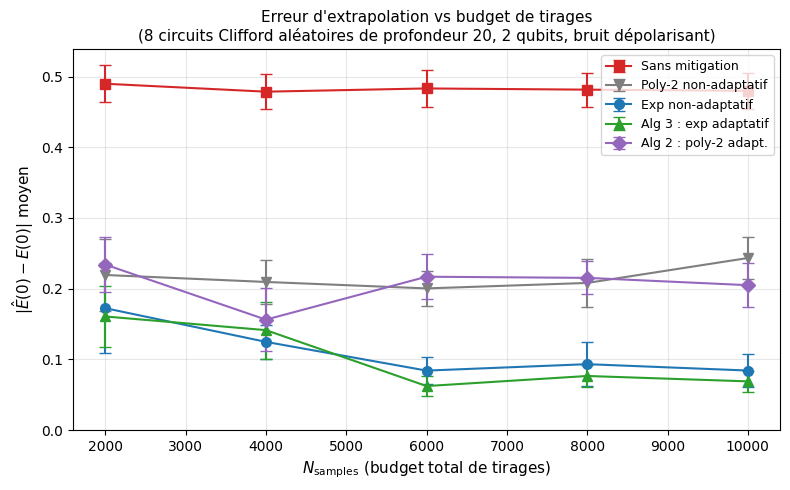

In [66]:
import matplotlib.pyplot as plt

labels = {
    'unmit':       ('Sans mitigation',        'tab:red',    's'),
    'poly2_nonad': ('Poly-2 non-adaptatif',   'tab:gray',   'v'),
    'exp_nonad':   ('Exp non-adaptatif',      'tab:blue',   'o'),
    'alg3':        ('Alg 3 : exp adaptatif',  'tab:green',  '^'),
    'alg2_poly2':  ('Alg 2 : poly-2 adapt.',  'tab:purple', 'D'),
}

plt.figure(figsize=(8, 5))
for m, (lab, c, mk) in labels.items():
    mean = np.array([np.mean(results[m][B]) for B in budgets])
    sem  = np.array([np.std(results[m][B], ddof=1) / np.sqrt(len(seeds)) for B in budgets])
    plt.errorbar(budgets, mean, yerr=sem, marker=mk, color=c, label=lab,
                 capsize=4, linewidth=1.5, markersize=7)

plt.xlabel(r'$N_\mathrm{samples}$ (budget total de tirages)', fontsize=11)
plt.ylabel(r'$|\hat E(0) - E(0)|$ moyen', fontsize=11)
plt.title(f'Erreur d\'extrapolation vs budget de tirages\n'
          f'({len(seeds)} circuits Clifford aléatoires de profondeur 20, 2 qubits, bruit dépolarisant)',
          fontsize=11)
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()